In [ ]:
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn import cluster
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [ ]:
from google.colab import files
uploaded = files.upload()
data = pd.read_csv("retail_transactions_segmentation.csv")

Saving retail_transactions_segmentation.csv to retail_transactions_segmentation (2).csv


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3663 entries, 0 to 3662
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       3663 non-null   int64  
 1   transaction_date  3663 non-null   object 
 2   amount            3663 non-null   float64
 3   product_category  3663 non-null   object 
dtypes: float64(1), int64(1), object(2)
memory usage: 114.6+ KB


In [ ]:
data.isnull().sum()

,0
customer_id,0
transaction_date,0
amount,0
product_category,0


In [ ]:
numeric_features =['customer_id' , 'amount']

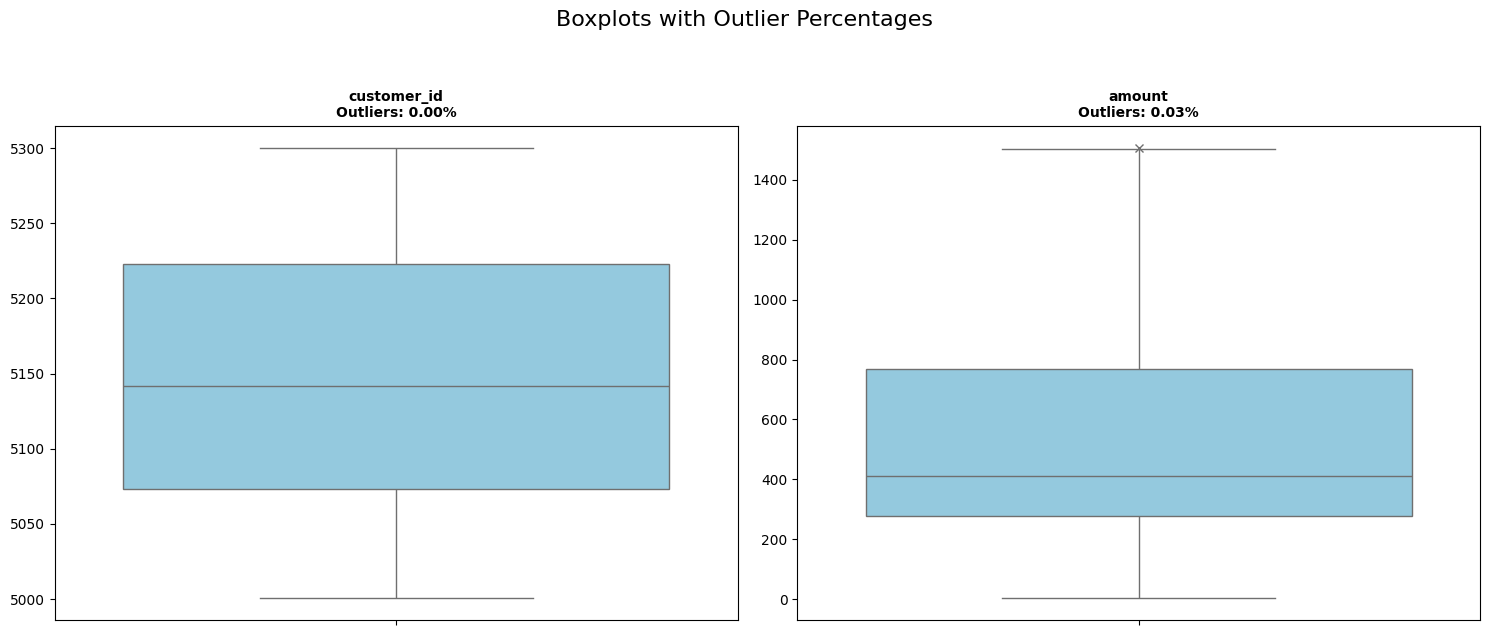

-------------------------------------------------------------------------------
customer_id: 0 outliers (0.00%)
-------------------------------------------------------------------------------
amount: 1 outliers (0.03%)


In [ ]:
# To check if there are outliers
fig, axes = plt.subplots(nrows=1, ncols=len(numeric_features), figsize=(15, 6))

for i, col in enumerate(numeric_features):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)]
    outlier_percentage = (len(outliers) / len(data)) * 100

    sns.boxplot(y=data[col], ax=axes[i], color='skyblue', flierprops={"marker": "x", "markerfacecolor": "red"})

    axes[i].set_title(f"{col}\nOutliers: {outlier_percentage:.2f}%", fontsize=10, fontweight='bold')
    axes[i].set_ylabel('')

plt.suptitle("Boxplots with Outlier Percentages", fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

for col in numeric_features:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers_count = len(data[(data[col] < Q1 - 1.5 * IQR) | (data[col] > Q3 + 1.5 * IQR)])
    print("-------------------------------------------------------------------------------")
    print(f"{col}: {outliers_count} outliers ({(outliers_count/len(data))*100:.2f}%)")

In [ ]:
data["transaction_date"]=pd.to_datetime(data["transaction_date"])
data["transaction_date"]

,transaction_date
0,2024-01-31
1,2024-07-03
2,2024-11-13
3,2024-03-11
4,2024-12-28
...,...
3658,2024-09-02
3659,2024-02-27
3660,2024-10-02
3661,2024-11-21


In [ ]:
reference_date= data['transaction_date'].max() + dt.timedelta(days=1)
reference_date


Timestamp('2024-12-31 00:00:00')

In [ ]:
RFM =(data.groupby("customer_id").agg(
        Recency=("transaction_date", lambda d: (reference_date - d.max()).days), # the result will be the Number of day
        Frequency=("transaction_date", "count"), # How many transaction the customer made?
        Monetary=("amount", "sum"),   # the total amount of spent for each customer
    )
    .reset_index()
)
print(f"RFM table: {RFM.shape[0]} customers x {RFM.shape[1]} columns")
RFM


RFM table: 300 customers x 4 columns


,customer_id,Recency,Frequency,Monetary
0,5001,2,16,5172.45
1,5002,23,18,6158.98
2,5003,37,3,654.12
3,5004,5,35,31050.88
4,5005,26,16,5700.91
...,...,...,...,...
295,5296,15,3,407.14
296,5297,5,19,6717.35
297,5298,59,5,891.46
298,5299,12,10,3564.39


In [ ]:
#Scaling the Features
'''
 Recency is in days, frequency is a small count, monetary is in currency units — very different scales.
 K-Means uses Euclidean distance, so without scaling, "Monetary" would dominate the clustering just because its numbers are bigger ,
 so "StandardScaler" will fixe that
'''
scale=StandardScaler()
RFM_scaled=scale.fit_transform(RFM[['Recency','Frequency','Monetary']])

pd.DataFrame(RFM_scaled,columns=['Recency','Frequency','Monetary']).describe().round(1)



,Recency,Frequency,Monetary
count,300.0,300.0,300.0
mean,-0.0,-0.0,0.0
std,1.0,1.0,1.0
min,-0.8,-1.1,-0.6
25%,-0.6,-0.8,-0.6
50%,-0.4,-0.2,-0.3
75%,0.3,0.4,-0.1
max,4.1,3.1,3.4


In [ ]:
K_range = range(1, 11)
inertia = []
silhouette_scores = []  # only defined for K >= 2

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = kmeans.fit_predict(RFM_scaled)
    inertia.append(kmeans.inertia_)

    if k >= 2:
        sil = silhouette_score(RFM_scaled, labels)
        silhouette_scores.append(sil)
        print(f"K={k}: Inertia = {kmeans.inertia_:,.1f} | Silhouette = {sil:.4f}")
    else:
        print(f"K={k}: Inertia = {kmeans.inertia_:,.1f} | Silhouette = N/A")

K=1: Inertia = 900.0 | Silhouette = N/A
K=2: Inertia = 394.2 | Silhouette = 0.6789
K=3: Inertia = 183.0 | Silhouette = 0.6782
K=4: Inertia = 93.4 | Silhouette = 0.5702
K=5: Inertia = 71.4 | Silhouette = 0.5232
K=6: Inertia = 50.3 | Silhouette = 0.5194
K=7: Inertia = 41.1 | Silhouette = 0.4626
K=8: Inertia = 30.2 | Silhouette = 0.4815
K=9: Inertia = 24.1 | Silhouette = 0.4822
K=10: Inertia = 21.1 | Silhouette = 0.4765


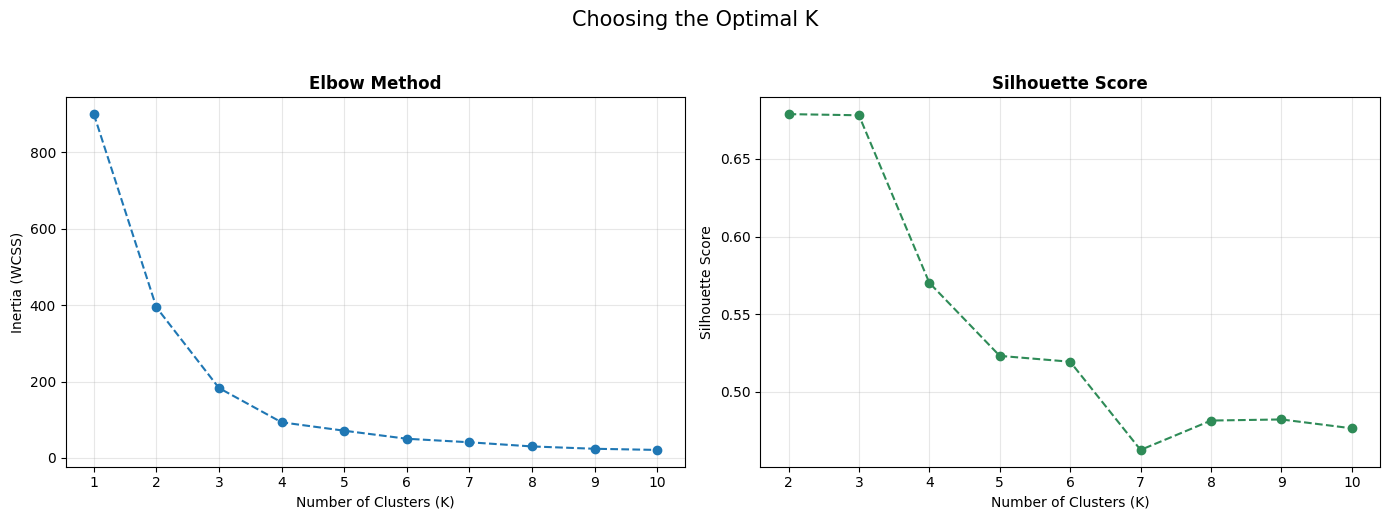

K with the highest silhouette score: 2 (0.6789)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertia, marker='o', linestyle='--')
axes[0].set_title("Elbow Method", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Number of Clusters (K)")
axes[0].set_ylabel("Inertia (WCSS)")
axes[0].set_xticks(K_range)
axes[0].grid(alpha=0.3)

sil_K = range(2, 11)
axes[1].plot(sil_K, silhouette_scores, marker='o', linestyle='--', color='seagreen')
axes[1].set_title("Silhouette Score", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Number of Clusters (K)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_xticks(sil_K)
axes[1].grid(alpha=0.3)

plt.suptitle("Choosing the Optimal K", fontsize=15, y=1.03)
plt.tight_layout()
plt.show()

best_k = list(sil_K)[np.argmax(silhouette_scores)]
print(f"K with the highest silhouette score: {best_k} ({max(silhouette_scores):.4f})")

In [ ]:
optimal_k = 3
# Baseed on highest silhouette score and elbow bend after adding another cluster
# 3 is the best k for maximum granularity which is more useful for an RFM data than maximum seperation using k =2

kmeans_final = KMeans(n_clusters=optimal_k, init='k-means++', n_init=10, random_state=42)
RFM['Cluster'] = kmeans_final.fit_predict(RFM_scaled)

print(RFM['Cluster'].value_counts().sort_index())

cluster_profile = RFM.groupby('Cluster').agg(
    Recency=('Recency', 'mean'),
    Frequency=('Frequency', 'mean'),
    Monetary=('Monetary', 'mean'),
    Customers=('customer_id', 'count')
).round(1)

cluster_profile

Cluster
0     40
1    238
2     22
Name: count, dtype: int64


,Recency,Frequency,Monetary,Customers
Cluster,,,,
0,8.4,35.0,29683.6,40
1,43.6,9.3,2876.9,238
2,258.6,2.1,326.1,22


## Cluster Profiling & Customer Personas

In [ ]:

# Add business-friendly persona names
persona_names = {
    0: 'Champions / VIP',
    1: 'Regular Customers',
    2: 'Dormant / At-Risk'
}

# Add Persona column to the cluster profile
cluster_profile['Persona'] = cluster_profile.index.map(persona_names)

# Calculate customer percentage
cluster_profile['Customer_%'] = (
    cluster_profile['Customers'] / cluster_profile['Customers'].sum() * 100
).round(1)

# Reorder columns
cluster_profile = cluster_profile[
    ['Persona', 'Customers', 'Customer_%', 'Recency', 'Frequency', 'Monetary']
]

cluster_profile

,Persona,Customers,Customer_%,Recency,Frequency,Monetary
Cluster,,,,,,
0,Champions / VIP,40,13.3,8.4,35.0,29683.6
1,Regular Customers,238,79.3,43.6,9.3,2876.9
2,Dormant / At-Risk,22,7.3,258.6,2.1,326.1


#####Cluster 0 — VIP Customers
Frequent, high-spending customers. Focus on loyalty and special offers.

##### Cluster 1 — Regular Customers
Average activity and spending. Use promotions to increase purchases.

##### Cluster 2 — Dormant Customers
Low activity and spending, with no recent purchases. Use offers to bring them back.



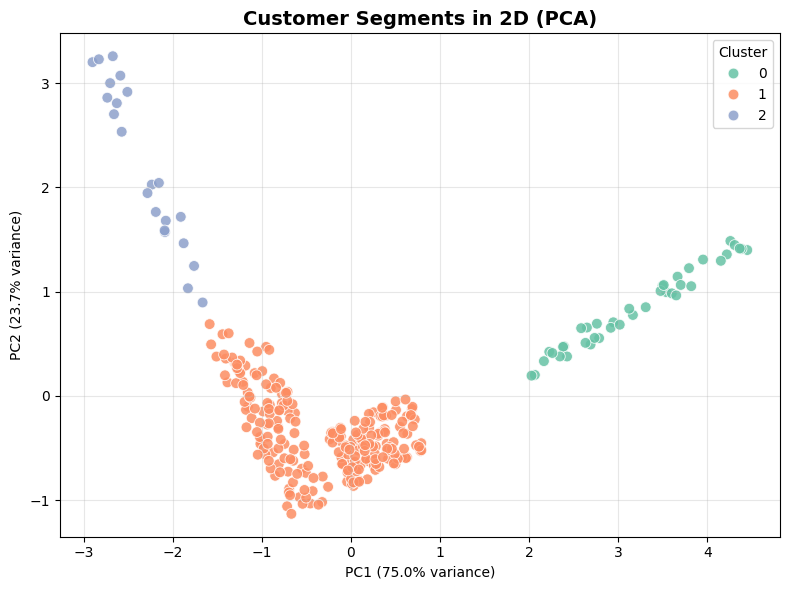

Total variance explained by PC1 + PC2: 98.7%


In [ ]:
# Reduce the scaled RFM features to 2 dimensions with PCA, just for plotting
pca = PCA(n_components=2, random_state=42)
RFM_pca = pca.fit_transform(RFM_scaled)

RFM['PCA1'] = RFM_pca[:, 0]
RFM['PCA2'] = RFM_pca[:, 1]

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=RFM, x='PCA1', y='PCA2',
    hue='Cluster', palette='Set2', s=60, alpha=0.85, edgecolor='white'
)
plt.title('Customer Segments in 2D (PCA)', fontsize=14, fontweight='bold')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.legend(title='Cluster')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Total variance explained by PC1 + PC2: {pca.explained_variance_ratio_.sum()*100:.1f}%')
